In [1]:
import pandas as pd
import numpy as np
import pyodbc
import sys
import os
import gc
from src.utils import read_query_file

project_path = r"C:\Users\Administrator\BDI-predator"

# add path to sys.path if not already added
if project_path not in sys.path:
    sys.path.append(project_path)

In [2]:
# functionalities
from src.calculation_features import (
    generate_rolling_features,
    label_risk_level_category,
    calculate_time_differences,
    calculate_rolling_txn_hour,
    create_ratio_features
)

In [3]:
# configs
from src.debit_card_config import (
    time_shift_config,
    time_windows,
    freq_config,
    dynamic_high_risk_config,
    duration_since_first_trnx_config,
    monetary_config_1,
    monetary_config_2,
    monetary_config_3,
    unique_count_config,
)
all_monetary_configs = (
    monetary_config_1 + monetary_config_2 + monetary_config_3
)

In [4]:
import pyarrow.parquet as pq

pq_file = pq.ParquetFile("data/backtest_all_data/DC_backtest_all_data_202505.parquet")

batches = []
for batch in pq_file.iter_batches(batch_size=1000000):
    batches.append(batch.to_pandas())

df_debit_clean = pd.concat(batches, ignore_index=True)

# Import Data

In [4]:
conn = pyodbc.connect(
    'DRIVER={SQL Server};SERVER=10.197.51.166;DATABASE=DataExtractionDB;UID=Predator_ML;PWD=predatorml'
)

In [5]:
start_date = "2025-05-01"
end_date = "2025-06-01"

In [6]:
query = read_query_file("sql/join_data/DC_backtest_all_data_202505.sql")
query = query.format(
    start_date = start_date,
    end_date = end_date
)

In [7]:
df_debit = pd.read_sql(query, conn)

C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_11316\3695941.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_debit = pd.read_sql(query, conn)


# Feature Preprocessing

In [8]:
df_debit['Transaction Datetime'] = pd.to_datetime(df_debit['Transaction Datetime'])
df_debit['CustomerSex'] = df_debit['CustomerSex'].where(df_debit['CustomerSex'].isin({"0","1","2"}), "N")
df_debit['HIghRiskCustomer'] = df_debit['HIghRiskCustomer'].where(df_debit['HIghRiskCustomer'].isin({"0","N"}), "N")

In [9]:
def is_convertible_to_float(x):
    try:
        float(x)
        return True
    except (ValueError, TypeError):
        return False

for col in ["MCC", "Country Code", "Currency Code", "POSMode"]:
    df_debit[col] = df_debit[col].astype(str)
    if col == "POSMode":
        df_debit[col] = df_debit[col].where(
            df_debit[col].apply(is_convertible_to_float), "__missing__"
        )
        df_debit[col] = df_debit[col].replace(
            to_replace=r"(?i)^nan$", value="__missing__", regex=True
        )
        df_debit[col] = df_debit[col].fillna("__missing__")
    else:
        df_debit[col] = df_debit[col].where(
            df_debit[col].apply(is_convertible_to_float), "-999"
        )
        df_debit[col] = df_debit[col].replace(
            to_replace=r"(?i)^nan$", value="-999", regex=True
        )
        df_debit[col] = df_debit[col].fillna("-999")

In [4]:
# df_debit.to_parquet("data/backtest_all_data/DC_backtest_all_data_202505.parquet")
# df_debit = pd.read_parquet("data/backtest_all_data/DC_backtest_all_data_202505.parquet")

In [10]:
def preprocess_data(df):
    print("Starting preprocessing...")
    df_processed = df.copy()

    # identify and safely downcast float columns
    float_cols = df_processed.select_dtypes(include=['float64', 'float32']).columns
    print(f"Float columns to downcast: {len(float_cols)}")
    for col in float_cols:
        try:
            print("Start downcasting float64 to float32")
            df_processed[col] = df_processed[col].astype('float32')
        except Exception as e:
            print(f"Warning: failed to downcast {col}: {e}")

    for col in df_processed.columns:
        if isinstance(col, str):
            try:
                if df_processed[col].dtype == 'object':
                    # treat pure whitespaces as missing
                    df_processed[col] = df_processed[col].replace(r'^\s*$', np.nan, regex=True)
                    
                    unique_vals = df_processed[col].dropna().unique()
                    if set(unique_vals).issubset({'Y', 'N'}):
                        print(f"Mapping Y/N to 1/0 in column: {col}")
                        df_processed[col] = df_processed[col].map({'N': 0, 'Y': 1})
                if col.startswith('Is') and df_processed[col].dtype in ['object', 'int64']:
                    print(f"Mapping Is* column Y/N to 1/0: {col}")
                    df_processed[col] = df_processed[col].map({'N': 0, 'Y': 1})
            except Exception as e:
                print(F"Warning processing column {col}: {e}")

    print("Estimated memory usage (MB):",
          df_processed.memory_usage(deep=True).sum() / 1e6)
    gc.collect()
    return df_processed

In [11]:
df_debit_clean = preprocess_data(df_debit)

Starting preprocessing...
Float columns to downcast: 8
Start downcasting float64 to float32
Start downcasting float64 to float32
Start downcasting float64 to float32
Start downcasting float64 to float32
Start downcasting float64 to float32
Start downcasting float64 to float32
Start downcasting float64 to float32
Start downcasting float64 to float32
Mapping Y/N to 1/0 in column: CustomerSex
Mapping Y/N to 1/0 in column: TotalTrxAmount30Mi
Estimated memory usage (MB): 4076.835412


In [12]:
df_debit_clean.to_parquet("data/backtest_all_data/DC_backtest_all_data_202505.parquet")

# Feature Engineering

## Txn Hour

In [5]:
df_txn_hour = calculate_rolling_txn_hour(
    df=df_debit_clean,
    group_col="Debit_No",
    datetime_col="Transaction Datetime",
    windows=time_windows
)

Processing TxnHour Rolling Avg: 100%|██████████| 1291363/1291363 [51:14<00:00, 419.98it/s]  


In [6]:
df_txn_hour = create_ratio_features(
    df_txn_hour,
    df_txn_hour.columns,
    "L15min",
    "L30D"
)

In [7]:
df_txn_hour.to_parquet("data/backtest_all_data/DC_features/df_txn_hour.parquet")
del df_txn_hour
gc.collect()

21

## RFM

### Recency: Time Difference

In [8]:
df_time_diff = calculate_time_differences(
    df=df_debit_clean,
    datetime_col="Transaction Datetime",
    groupby_col="Debit_No",
    time_window=time_windows,
    config=time_shift_config,
)

Calculating rolling averages: 100%|██████████| 2/2 [02:09<00:00, 64.71s/it]


In [9]:
df_time_diff.to_parquet("data/backtest_all_data/DC_features/df_time_diff.parquet")
del df_time_diff
gc.collect()

0

### Recency: Time Duration From First Txn to Current

In [10]:
df_firsttxn_to_current = generate_rolling_features(
    df=df_debit_clean,
    datetime_col="Transaction Datetime",
    key_col="Transaction Serial No",
    features_config=duration_since_first_trnx_config
)

Feature Config Progress: 100%|██████████| 2/2 [07:42<00:00, 231.34s/it]             


In [11]:
for groupby_col in ["MCC","Country Code"]:
    # get first transaction time per target group within each primary group
    df_firsttxn_to_current[f"FirstTxnBy{groupby_col.replace(" ","")}"] = df_firsttxn_to_current.groupby(["Debit_No", groupby_col])[
        "Transaction Datetime"
    ].transform("first")

    # calculate duration in minutes
    amount_col = f"TimeFirstTxnToCurrent{groupby_col}"
    df_firsttxn_to_current[amount_col] = (
        df_firsttxn_to_current["Transaction Datetime"] - df_firsttxn_to_current[f"FirstTxnBy{groupby_col.replace(" ","")}"]
    ).dt.total_seconds() / 60

    df_firsttxn_to_current = df_firsttxn_to_current.drop(f"FirstTxnBy{groupby_col.replace(" ","")}", axis=1)

In [12]:
df_firsttxn_to_current = create_ratio_features(
    df_firsttxn_to_current,
    df_firsttxn_to_current.columns,
    "L15min",
    "L30D"
)

In [13]:
df_firsttxn_to_current.to_parquet("data/backtest_all_data/DC_features/df_firsttxn_to_current.parquet")
del df_firsttxn_to_current
gc.collect()

0

### Frequency

In [5]:
card_no_ever_alert = list(
    df_debit_clean[df_debit_clean['Confirmed'].isin([0,1])]
    .Debit_No.unique()
)
card_no_never_alert = list(
    df_debit_clean[~df_debit_clean.Debit_No
    .isin(card_no_ever_alert)].Debit_No.unique()
)

In [15]:
import gc

# split the lists into 50:50
ever_alert_part_1, ever_alert_part_2 = np.array_split(card_no_ever_alert, 2)
never_alert_part_1, never_alert_part_2, never_alert_part_3, never_alert_part_4 = np.array_split(card_no_never_alert, 4)

# create dictionary to store the splits and their labels for iteration
splits = {
    'ever_alert_part_1': ever_alert_part_1,
    'ever_alert_part_2': ever_alert_part_2,
    'never_alert_part_1': never_alert_part_1,
    'never_alert_part_2': never_alert_part_2,
    'never_alert_part_3': never_alert_part_3,
    'never_alert_part_4': never_alert_part_4,
}

# loop over splits, filter dataframe, run feature generation, and save parquet
for name, pan_list, in splits.items():
    print(f"Processing {name}...")
    df_filtered = df_debit_clean[df_debit_clean.Debit_No.isin(pan_list)]

    # run feature engineering
    df_freq = generate_rolling_features(
        df_filtered,
        datetime_col="Transaction Datetime",
        key_col="Transaction Serial No",
        features_config=freq_config,
    )

    df_freq = create_ratio_features(
        df_freq,
        df_freq.columns,
        "L15min",
        "L30D"
    )

    # save parquet
    output_path = f"data/backtest_all_data/DC_features/df_freq_{name}.parquet"
    df_freq.to_parquet(output_path)

    # clean up memory
    del df_filtered
    del df_freq
    gc.collect()

    print(f"Finished {name}, saved to {output_path}\n")

Processing ever_alert_part_1...


frequency Windows Progress:   0%|          | 0/2 [00:00<?, ?it/s]
                                                                 
Feature Config Progress: 100%|██████████| 4/4 [00:00<00:00, 13.02it/s]


Finished ever_alert_part_1, saved to data/backtest_all_data/DC_features/df_freq_ever_alert_part_1.parquet

Processing ever_alert_part_2...


frequency Windows Progress:   0%|          | 0/2 [00:00<?, ?it/s]
                                                                 
frequency Windows Progress:   0%|          | 0/2 [00:00<?, ?it/s]
                                                                 
Feature Config Progress: 100%|██████████| 4/4 [00:00<00:00, 15.73it/s]


Finished ever_alert_part_2, saved to data/backtest_all_data/DC_features/df_freq_ever_alert_part_2.parquet

Processing never_alert_part_1...


...

Finished never_alert_part_2, saved to data/backtest_all_data/DC_features/df_freq_never_alert_part_2.parquet

Processing never_alert_part_3...


Feature Config Progress: 100%|██████████| 4/4 [02:07<00:00, 31.76s/it]   


Finished never_alert_part_3, saved to data/backtest_all_data/DC_features/df_freq_never_alert_part_3.parquet

Processing never_alert_part_4...


Feature Config Progress: 100%|██████████| 4/4 [01:54<00:00, 28.54s/it]   


Finished never_alert_part_4, saved to data/backtest_all_data/DC_features/df_freq_never_alert_part_4.parquet



### Monetary

In [7]:
# split the lists into 50:50
ever_alert_part_1, ever_alert_part_2 = np.array_split(card_no_ever_alert, 2)
never_alert_part_1, never_alert_part_2, never_alert_part_3, never_alert_part_4 = np.array_split(card_no_never_alert, 4)

# create dictionary to store the splits and their labels for iteration
splits = {
    'ever_alert_part_1': ever_alert_part_1,
    'ever_alert_part_2': ever_alert_part_2,
    'never_alert_part_1': never_alert_part_1,
    'never_alert_part_2': never_alert_part_2,
    'never_alert_part_3': never_alert_part_3,
    'never_alert_part_4': never_alert_part_4,
}

# loop over splits, filter dataframe, run feature generation, and save parquet
for name, pan_list, in splits.items():
    print(f"Processing {name}...")
    df_filtered = df_debit_clean[df_debit_clean.Debit_No.isin(pan_list)]

    # run feature engineering
    df_monetary = generate_rolling_features(
        df_filtered,
        datetime_col="Transaction Datetime",
        key_col="Transaction Serial No",
        features_config=all_monetary_configs,
    )

    df_monetary = create_ratio_features(
        df_monetary,
        df_monetary.columns,
        "L15min",
        "L30D"
    )

    # save parquet
    output_path = f"data/backtest_all_data/DC_features/df_monetary_{name}.parquet"
    df_monetary.to_parquet(output_path)

    # clean up memory
    del df_filtered
    del df_monetary
    gc.collect()

    print(f"Finished {name}, saved to {output_path}\n")

Processing ever_alert_part_1...


monetary Windows Progress:   0%|          | 0/2 [00:00<?, ?it/s]
                                                                
monetary Windows Progress:   0%|          | 0/2 [00:00<?, ?it/s]
                                                                
monetary Windows Progress:   0%|          | 0/2 [00:00<?, ?it/s]
                                                                
monetary Windows Progress:   0%|          | 0/2 [00:00<?, ?it/s]
                                                                
Feature Config Progress: 100%|██████████| 9/9 [00:00<00:00, 15.05it/s]


Finished ever_alert_part_1, saved to data/backtest_all_data/DC_features/df_monetary_ever_alert_part_1.parquet

Processing ever_alert_part_2...


monetary Windows Progress:   0%|          | 0/2 [00:00<?, ?it/s]
                                                                
monetary Windows Progress:   0%|          | 0/2 [00:00<?, ?it/s]
                                                                
monetary Windows Progress:   0%|          | 0/2 [00:00<?, ?it/s]
                                                                
monetary Windows Progress:   0%|          | 0/2 [00:00<?, ?it/s]
                                                                
Feature Config Progress: 100%|██████████| 9/9 [00:00<00:00, 17.82it/s]


Finished ever_alert_part_2, saved to data/backtest_all_data/DC_features/df_monetary_ever_alert_part_2.parquet

Processing never_alert_part_1...


...

Finished never_alert_part_2, saved to data/backtest_all_data/DC_features/df_monetary_never_alert_part_2.parquet

Processing never_alert_part_3...


Feature Config Progress: 100%|██████████| 9/9 [04:42<00:00, 31.44s/it]  


Finished never_alert_part_3, saved to data/backtest_all_data/DC_features/df_monetary_never_alert_part_3.parquet

Processing never_alert_part_4...


Feature Config Progress: 100%|██████████| 9/9 [04:14<00:00, 28.28s/it]  


Finished never_alert_part_4, saved to data/backtest_all_data/DC_features/df_monetary_never_alert_part_4.parquet



### Unique Count

In [6]:
df_debit_clean["MCC Num"], uniques = df_debit_clean["MCC"].factorize()
df_debit_clean["Debit_No Num"], uniques = df_debit_clean["Debit_No"].factorize()

# split the lists into 50:50
ever_alert_part_1, ever_alert_part_2 = np.array_split(card_no_ever_alert, 2)
never_alert_part_1, never_alert_part_2, never_alert_part_3, never_alert_part_4, never_alert_part_5, never_alert_part_6 = np.array_split(card_no_never_alert, 6)

In [7]:
print(len(df_debit_clean[df_debit_clean.Debit_No.isin(never_alert_part_4)]))
print(len(df_debit_clean[df_debit_clean.Debit_No.isin(never_alert_part_5)]))
print(len(df_debit_clean[df_debit_clean.Debit_No.isin(never_alert_part_6)]))

557370
411940
293855


In [8]:
# create dictionary to store the splits and their labels for iteration
splits = {
    'ever_alert_part_1': ever_alert_part_1,
    'ever_alert_part_2': ever_alert_part_2,
    # 'never_alert_part_1': never_alert_part_1,
    # 'never_alert_part_2': never_alert_part_2,
    # 'never_alert_part_3': never_alert_part_3,
    'never_alert_part_4': never_alert_part_4,
    'never_alert_part_5': never_alert_part_5,
    'never_alert_part_6': never_alert_part_6,
}

# loop over splits, filter dataframe, run feature generation, and save parquet
for name, pan_list, in splits.items():
    print(f"Processing {name}...")
    df_filtered = df_debit_clean[df_debit_clean.Debit_No.isin(pan_list)]

    # run feature engineering
    df_unique_count = generate_rolling_features(
        df_filtered,
        datetime_col="Transaction Datetime",
        key_col="Transaction Serial No",
        features_config=unique_count_config,
    )

    df_unique_count = create_ratio_features(
        df_unique_count,
        df_unique_count.columns,
        "L15min",
        "L30D"
    )

    # save parquet
    output_path = f"data/backtest_all_data/DC_features/df_unique_count_{name}.parquet"
    df_unique_count.to_parquet(output_path)

    # clean up memory
    del df_filtered
    del df_unique_count
    gc.collect()

    print(f"Finished {name}, saved to {output_path}\n")

Processing ever_alert_part_1...


unique Windows Progress:   0%|          | 0/2 [00:00<?, ?it/s]C:\Users\Administrator\BDI-predator\ml-fraud\src\calculation_features.py:414: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset[datetime_col] = pd.to_datetime(dataset[datetime_col])

unique Windows Progress:  50%|█████     | 1/2 [00:00<00:00,  1.10it/s]C:\Users\Administrator\BDI-predator\ml-fraud\src\calculation_features.py:414: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset[datetime_col] = pd.to_datetime(dataset[datetime_col])

Featur

Finished ever_alert_part_1, saved to data/backtest_all_data/DC_features/df_unique_count_ever_alert_part_1.parquet

Processing ever_alert_part_2...


unique Windows Progress:   0%|          | 0/2 [00:00<?, ?it/s]C:\Users\Administrator\BDI-predator\ml-fraud\src\calculation_features.py:414: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset[datetime_col] = pd.to_datetime(dataset[datetime_col])

unique Windows Progress:  50%|█████     | 1/2 [00:00<00:00,  1.59it/s]C:\Users\Administrator\BDI-predator\ml-fraud\src\calculation_features.py:414: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset[datetime_col] = pd.to_datetime(dataset[datetime_col])

Featur

Finished ever_alert_part_2, saved to data/backtest_all_data/DC_features/df_unique_count_ever_alert_part_2.parquet

Processing never_alert_part_4...


...

Finished never_alert_part_4, saved to data/backtest_all_data/DC_features/df_unique_count_never_alert_part_4.parquet

Processing never_alert_part_5...


unique Windows Progress:   0%|          | 0/2 [00:00<?, ?it/s]C:\Users\Administrator\BDI-predator\ml-fraud\src\calculation_features.py:414: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset[datetime_col] = pd.to_datetime(dataset[datetime_col])

unique Windows Progress:  50%|█████     | 1/2 [00:43<00:43, 43.43s/it]C:\Users\Administrator\BDI-predator\ml-fraud\src\calculation_features.py:414: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset[datetime_col] = pd.to_datetime(dataset[datetime_col])

Featur

Finished never_alert_part_5, saved to data/backtest_all_data/DC_features/df_unique_count_never_alert_part_5.parquet

Processing never_alert_part_6...


unique Windows Progress:   0%|          | 0/2 [00:00<?, ?it/s]C:\Users\Administrator\BDI-predator\ml-fraud\src\calculation_features.py:414: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset[datetime_col] = pd.to_datetime(dataset[datetime_col])

unique Windows Progress:  50%|█████     | 1/2 [00:30<00:30, 30.89s/it]C:\Users\Administrator\BDI-predator\ml-fraud\src\calculation_features.py:414: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset[datetime_col] = pd.to_datetime(dataset[datetime_col])

Featur

Finished never_alert_part_6, saved to data/backtest_all_data/DC_features/df_unique_count_never_alert_part_6.parquet



# Join All Data

In [5]:
df_freq_ever_alert_part_1 = pd.read_parquet("data/backtest_all_data/DC_features/df_freq_ever_alert_part_1.parquet")
df_freq_ever_alert_part_2 = pd.read_parquet("data/backtest_all_data/DC_features/df_freq_ever_alert_part_2.parquet")
df_freq_never_alert_part_1 = pd.read_parquet("data/backtest_all_data/DC_features/df_freq_never_alert_part_1.parquet")
df_freq_never_alert_part_2 = pd.read_parquet("data/backtest_all_data/DC_features/df_freq_never_alert_part_2.parquet")
df_freq_never_alert_part_3 = pd.read_parquet("data/backtest_all_data/DC_features/df_freq_never_alert_part_3.parquet")
df_freq_never_alert_part_4 = pd.read_parquet("data/backtest_all_data/DC_features/df_freq_never_alert_part_4.parquet")

df_freq = pd.concat([
    df_freq_ever_alert_part_1,
    df_freq_ever_alert_part_2,
    df_freq_never_alert_part_1,
    df_freq_never_alert_part_2,
    df_freq_never_alert_part_3,
    df_freq_never_alert_part_4
], axis=0).reset_index(drop=True)
del df_freq_ever_alert_part_1
del df_freq_ever_alert_part_2
del df_freq_never_alert_part_1
del df_freq_never_alert_part_2
del df_freq_never_alert_part_3
del df_freq_never_alert_part_4
gc.collect()

40

In [6]:
df_monetary_ever_alert_part_1 = pd.read_parquet("data/backtest_all_data/DC_features/df_monetary_ever_alert_part_1.parquet")
df_monetary_ever_alert_part_2 = pd.read_parquet("data/backtest_all_data/DC_features/df_monetary_ever_alert_part_2.parquet")
df_monetary_never_alert_part_1 = pd.read_parquet("data/backtest_all_data/DC_features/df_monetary_never_alert_part_1.parquet")
df_monetary_never_alert_part_2 = pd.read_parquet("data/backtest_all_data/DC_features/df_monetary_never_alert_part_2.parquet")
df_monetary_never_alert_part_3 = pd.read_parquet("data/backtest_all_data/DC_features/df_monetary_never_alert_part_3.parquet")
df_monetary_never_alert_part_4 = pd.read_parquet("data/backtest_all_data/DC_features/df_monetary_never_alert_part_4.parquet")

df_monetary = pd.concat([
    df_monetary_ever_alert_part_1,
    df_monetary_ever_alert_part_2,
    df_monetary_never_alert_part_1,
    df_monetary_never_alert_part_2,
    df_monetary_never_alert_part_3,
    df_monetary_never_alert_part_4
], axis=0).reset_index(drop=True)
del df_monetary_ever_alert_part_1
del df_monetary_ever_alert_part_2
del df_monetary_never_alert_part_1
del df_monetary_never_alert_part_2
del df_monetary_never_alert_part_3
del df_monetary_never_alert_part_4
gc.collect()

0

In [7]:
df_unique_count_ever_alert_part_1 = pd.read_parquet("data/backtest_all_data/DC_features/df_unique_count_ever_alert_part_1.parquet")
df_unique_count_ever_alert_part_2 = pd.read_parquet("data/backtest_all_data/DC_features/df_unique_count_ever_alert_part_2.parquet")
# df_unique_count_never_alert_part_1 = pd.read_parquet("data/backtest_all_data/DC_features/df_unique_count_never_alert_part_1.parquet")
# df_unique_count_never_alert_part_2 = pd.read_parquet("data/backtest_all_data/DC_features/df_unique_count_never_alert_part_2.parquet")
# df_unique_count_never_alert_part_3 = pd.read_parquet("data/backtest_all_data/DC_features/df_unique_count_never_alert_part_3.parquet")
df_unique_count_never_alert_part_4 = pd.read_parquet("data/backtest_all_data/DC_features/df_unique_count_never_alert_part_4.parquet")
df_unique_count_never_alert_part_5 = pd.read_parquet("data/backtest_all_data/DC_features/df_unique_count_never_alert_part_5.parquet")
df_unique_count_never_alert_part_6 = pd.read_parquet("data/backtest_all_data/DC_features/df_unique_count_never_alert_part_6.parquet")

df_unique_count = pd.concat([
    df_unique_count_ever_alert_part_1,
    df_unique_count_ever_alert_part_2,
    # df_unique_count_never_alert_part_1,
    # df_unique_count_never_alert_part_2,
    # df_unique_count_never_alert_part_3,
    df_unique_count_never_alert_part_4,
    df_unique_count_never_alert_part_5,
    df_unique_count_never_alert_part_6
], axis=0).reset_index(drop=True)
del df_unique_count_ever_alert_part_1
del df_unique_count_ever_alert_part_2
del df_unique_count_never_alert_part_4
del df_unique_count_never_alert_part_5
del df_unique_count_never_alert_part_6
gc.collect()

0

In [8]:
df_time_diff = pd.read_parquet("data/backtest_all_data/DC_features/df_time_diff.parquet")
df_txn_hour = pd.read_parquet("data/backtest_all_data/DC_features/df_txn_hour.parquet")
df_firsttxn_to_current = pd.read_parquet("data/backtest_all_data/DC_features/df_firsttxn_to_current.parquet")

In [9]:
# ratio 1
df_debit_clean['RatioTrxAmountL1DL5min'] = df_debit_clean['TotalTrxAmountL1D']/df_debit_clean['TotalTrxAmountL5min']
df_debit_clean['RatioTrxAmountL1DL5min'] = df_debit_clean['RatioTrxAmountL1DL5min'].replace([np.inf, -np.inf], np.nan)
df_debit_clean['RatioTrxAmountL1DL5min'] = df_debit_clean['RatioTrxAmountL1DL5min'].fillna(-999)

# ratio 2
df_debit_clean['RatioTrxAmountL1DL15min'] = df_debit_clean['TotalTrxAmountL1D']/df_debit_clean['TotalTrxAmount15Mi']
df_debit_clean['RatioTrxAmountL1DL15min'] = df_debit_clean['RatioTrxAmountL1DL15min'].replace([np.inf, -np.inf], np.nan)
df_debit_clean['RatioTrxAmountL1DL15min'] = df_debit_clean['RatioTrxAmountL1DL15min'].fillna(-999)

# ratio 3
df_debit_clean['RatioTrxAmountL1DL10min'] = df_debit_clean['TotalTrxAmountL1D']/df_debit_clean['TotalTrxAmount10Mi']
df_debit_clean['RatioTrxAmountL1DL10min'] = df_debit_clean['RatioTrxAmountL1DL10min'].replace([np.inf, -np.inf], np.nan)
df_debit_clean['RatioTrxAmountL1DL10min'] = df_debit_clean['RatioTrxAmountL1DL10min'].fillna(-999)

In [10]:
# Define the common keys for merging
merge_keys = ["Transaction Serial No", "Debit_No"]

# Extract columns
time_shift_cols = list(time_shift_config.keys())
freq_cols = [col for col in df_freq.columns if 'txncount' in col.lower()]
unique_count_cols = [col for col in df_unique_count.columns if 'cntunique' in col.lower()]
monetary_cols = [col for col in df_monetary.columns if 'amt' in col.lower()]
firsttxn_to_current_cols = [
    col for col in df_firsttxn_to_current.columns if "TimeFirstTxnToCurrent" in col
]
txn_hour_cols = [
    col for col in df_txn_hour.columns if "TxnHour" in col
]

In [11]:
from functools import reduce

card_list = list(df_unique_count['Transaction Serial No'])

# Subset dataframes
df_time_diff = df_time_diff[df_time_diff.Debit_No.isin(card_list)][merge_keys + time_shift_cols]
df_freq = df_freq[df_freq.Debit_No.isin(card_list)][merge_keys + freq_cols]
df_monetary = df_monetary[df_monetary.Debit_No.isin(card_list)][merge_keys + monetary_cols]
df_firsttxn_to_current = df_firsttxn_to_current[df_firsttxn_to_current.Debit_No.isin(card_list)][merge_keys + firsttxn_to_current_cols]
df_txn_hour = df_txn_hour[df_txn_hour.Debit_No.isin(card_list)][merge_keys + txn_hour_cols]
df_unique_count = df_unique_count[merge_keys + unique_count_cols]

# Merge all feature dataframes
dfs_to_merge = [
    df_time_diff,
    df_freq,
    df_monetary,
    df_unique_count,
    df_firsttxn_to_current,
    df_txn_hour
]
df_debit_final = reduce(
    lambda left, right: pd.merge(left, right, on=merge_keys, how="outer"), dfs_to_merge
)

del df_time_diff
del df_freq
del df_monetary
del df_unique_count
del df_firsttxn_to_current
del df_txn_hour

In [14]:
# Merge with additional features
og_cols = [
    'Debit_No',
    'Transaction Serial No',
    'Transaction Datetime',
    'Transaction Amount',
    'CustomerAge',
    'CustomerSex',
    'TotalTrxAmountL5min',
    'TotalTrxAmount10Mi',
    'TotalTrxAmount15Mi',
    'TotalTrxAmount30Mi',
    'TotalTrxAmountL1D',
    'RatioTrxAmountL1DL5min',
    'RatioTrxAmountL1DL15min',
    'RatioTrxAmountL1DL10min',
    'CountTrxTrf',
    'POSMode',
    'HIghRiskCustomer',
    'Confirmed'
]

df_debit_final = df_debit_final.merge(
    df_debit_clean[og_cols],
    on=merge_keys,
    how="left",
)

In [16]:
df_debit_final.rename(columns={
    'Transaction Amount': 'TransactionAmount',
    'AvgTxnHourL30D': 'AvgTrnxHourL30d',
    'AvgTxnHourL900s': 'AvgTrnxHourL15min',
    'HIghRiskCustomer': 'HighRiskCustomer'
}, inplace=True)

In [17]:
df_debit_final[[
    'Transaction Serial No',
    'Confirmed',
    'Transaction Datetime',
    'SumAmtL30D',
    'TxnCountL30D',
    'CountTrxTrf',
    'TotalTrxAmount10Mi',
    'TotalTrxAmountL5min',
    'TotalTrxAmount15Mi',
    'CntUniqueCardNoByMCCL30D',
    'TotalTrxAmountL1D',
    'TransactionAmount',
    'CustomerAge',
    'RatioTrxAmountL1DL15min',
    'RatioTrxAmountL1DL10min',
    'RatioTrxAmountL1DL5min',
    'MaxAmtL30D',
    'AvgAmtL30D',
    'RatioCntUniqueCardNoByMCCL30DL15min',
    'RatioTxnCountL30DL15min',
    'AvgTrnxHourL30d',
    'TxnTimeDifference',
    'TimeFirstTxnToCurrentMCC',
    'AvgTimeFirstTxnToCurrentMCCL30D',
    'AvgTrnxHourL15min',
    'CntUniqueCardNoByMCCL15min',
    'HighRiskCustomer',
    'POSMode'
]].to_parquet("data/backtest_all_data/DC_backtest_ready_202505.parquet")

# Backtest/Validate Model

In [2]:
import pickle

filepath_base_rf = "model/debit/base_rf_ros_31_feats_20250702.pkl"
with open(filepath_base_rf, "rb") as f:
    base_rf = pickle.load(f)

In [3]:
df_final = pd.read_parquet("data/ready_to_train/df_debit_final_25_feats_20250702.parquet")

In [4]:
# setup pipeline
from src.model_pipeline import ModelPipeline

pipeline_rf = ModelPipeline(model_type="random_forest", random_state=42)

split_date = '2025-05-01'
df_splits = pipeline_rf.split_data_by_date(
    df=df_final,
    date_column="Transaction Datetime",
    split_date=split_date
)

Initializing ModelPipeline with model type: random_forest
Retrieving model instance for type: random_forest
Splitting data by date (pre-preprocessing)...
Train samples: 647760, Test samples: 66974
Data splitting complete.


In [5]:
# prepare train data
target_col = "Confirmed"
X, y = pipeline_rf.prepare_data(
    df=df_splits["df_train"],
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_apply_one_hot=True,
    is_apply_log=False,
    is_impute_median=False,
    is_training=True
)

Preparing data (is_training=True)...
Starting core numeric and boolean preprocessing...
Core numeric and boolean preprocessing complete.
Fitting CategoryManager...
  Fitted categories for column 'HighRiskCustomer': ['0', 'N', '__missing__']
  Fitted categories for column 'POSMode': ['0', '1', '2', '5', '7', '9', '__missing__']
CategoryManager fitting complete.
Transforming data using CategoryManager...
CategoryManager transformation complete.
Applying One-Hot Encoders for column: Index(['HighRiskCustomer', 'POSMode'], dtype='object')...
Identified numerical columns for imputation: ['SumAmtL30D', 'TxnCountL30D', 'CountTrxTrf', 'TotalTrxAmount10Mi', 'TotalTrxAmountL5min', 'TotalTrxAmount15Mi', 'CntUniqueCardNoByMCCL30D', 'TotalTrxAmountL1D', 'TransactionAmount', 'CustomerAge', 'RatioTrxAmountL1DL15min', 'RatioTrxAmountL1DL10min', 'RatioTrxAmountL1DL5min', 'MaxAmtL30D', 'AvgAmtL30D', 'RatioCntUniqueCardNoByMCCL30DL15min', 'RatioTxnCountL30DL15min', 'AvgTrnxHourL30d', 'TxnTimeDifference', 

In [6]:
df_backtest = pd.read_parquet("data/backtest_all_data/DC_backtest_ready_202505.parquet")
df_backtest.set_index("Transaction Serial No", drop=True, inplace=True)
df_backtest["Confirmed"] = df_backtest["Confirmed"].fillna(False)
df_backtest["Confirmed"] = df_backtest["Confirmed"].astype(int)

In [9]:
list(X.columns)

['SumAmtL30D',
 'TxnCountL30D',
 'CountTrxTrf',
 'TotalTrxAmount10Mi',
 'TotalTrxAmountL5min',
 'TotalTrxAmount15Mi',
 'CntUniqueCardNoByMCCL30D',
 'TotalTrxAmountL1D',
 'TransactionAmount',
 'CustomerAge',
 'RatioTrxAmountL1DL15min',
 'RatioTrxAmountL1DL10min',
 'RatioTrxAmountL1DL5min',
 'MaxAmtL30D',
 'AvgAmtL30D',
 'RatioCntUniqueCardNoByMCCL30DL15min',
 'RatioTxnCountL30DL15min',
 'AvgTrnxHourL30d',
 'TxnTimeDifference',
 'TimeFirstTxnToCurrentMCC',
 'AvgTimeFirstTxnToCurrentMCCL30D',
 'AvgTrnxHourL15min',
 'CntUniqueCardNoByMCCL15min',
 'HighRiskCustomer_N',
 'HighRiskCustomer___missing__',
 'POSMode_1',
 'POSMode_2',
 'POSMode_5',
 'POSMode_7',
 'POSMode_9',
 'POSMode___missing__']

In [7]:
# preprocessed backtest data
X_backtest, y_backtest = pipeline_rf.prepare_data(
    df=df_backtest,
    target_column=target_col,
    exclude_columns=None,
    is_apply_one_hot=True,
    is_apply_log=False,
    is_impute_median=False,
    is_training=False
)

Preparing data (is_training=False)...
Starting core numeric and boolean preprocessing...
Core numeric and boolean preprocessing complete.
Transforming data using CategoryManager...
CategoryManager transformation complete.
Applying One-Hot Encoders for column: Index(['HighRiskCustomer', 'POSMode'], dtype='object')...
Identified numerical columns for imputation: ['SumAmtL30D', 'TxnCountL30D', 'CountTrxTrf', 'TotalTrxAmount10Mi', 'TotalTrxAmountL5min', 'TotalTrxAmount15Mi', 'CntUniqueCardNoByMCCL30D', 'TotalTrxAmountL1D', 'TransactionAmount', 'CustomerAge', 'RatioTrxAmountL1DL15min', 'RatioTrxAmountL1DL10min', 'RatioTrxAmountL1DL5min', 'MaxAmtL30D', 'AvgAmtL30D', 'RatioCntUniqueCardNoByMCCL30DL15min', 'RatioTxnCountL30DL15min', 'AvgTrnxHourL30d', 'TxnTimeDifference', 'TimeFirstTxnToCurrentMCC', 'AvgTimeFirstTxnToCurrentMCCL30D', 'AvgTrnxHourL15min', 'CntUniqueCardNoByMCCL15min']
Identified categorical columns (encoded): []
Transforming data using NumericalImputer...
  Imputed column 'SumA

In [10]:
X_backtest = X_backtest[
    ['SumAmtL30D',
    'TxnCountL30D',
    'CountTrxTrf',
    'TotalTrxAmount10Mi',
    'TotalTrxAmountL5min',
    'TotalTrxAmount15Mi',
    'CntUniqueCardNoByMCCL30D',
    'TotalTrxAmountL1D',
    'TransactionAmount',
    'CustomerAge',
    'RatioTrxAmountL1DL15min',
    'RatioTrxAmountL1DL10min',
    'RatioTrxAmountL1DL5min',
    'MaxAmtL30D',
    'AvgAmtL30D',
    'RatioCntUniqueCardNoByMCCL30DL15min',
    'RatioTxnCountL30DL15min',
    'AvgTrnxHourL30d',
    'TxnTimeDifference',
    'TimeFirstTxnToCurrentMCC',
    'AvgTimeFirstTxnToCurrentMCCL30D',
    'AvgTrnxHourL15min',
    'CntUniqueCardNoByMCCL15min',
    'HighRiskCustomer_N',
    'HighRiskCustomer___missing__',
    'POSMode_1',
    'POSMode_2',
    'POSMode_5',
    'POSMode_7',
    'POSMode_9',
    'POSMode___missing__']
]

In [11]:
df_pred = X_backtest[['TransactionAmount']]
df_pred['P_Bad'] = base_rf.predict_proba(X_backtest)[:, 1]
df_pred['Confirmed'] = y_backtest

C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_3296\398676721.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pred['P_Bad'] = base_rf.predict_proba(X_backtest)[:, 1]
C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_3296\398676721.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pred['Confirmed'] = y_backtest


In [12]:
df_pred.to_parquet("data/backtest_all_data/DC_backtest_result_202505.parquet")

# Score Analysis

In [4]:
df_pred = pd.read_parquet("data/backtest_all_data/DC_backtest_result_202505.parquet")

In [5]:
conn = pyodbc.connect(
    'DRIVER={SQL Server};SERVER=10.197.51.166;DATABASE=DataExtractionDB;UID=Predator_ML;PWD=predatorml'
)
start_date = "2025-05-01"
end_date = "2025-06-01"

In [6]:
query = read_query_file("sql/join_data/DC_202505_triggered_rules.sql")
query = query.format(
    start_date = start_date,
    end_date = end_date
)

In [7]:
df_cc_triggered_rules = pd.read_sql(query, conn)

C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_1320\2608064737.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cc_triggered_rules = pd.read_sql(query, conn)


In [8]:
df_cc_triggered_rules.set_index('Transaction Serial No', inplace=True)

In [9]:
df_rules_ml = pd.merge(
    df_cc_triggered_rules[['Triggered_Rules','Alert']],
    df_pred,
    left_index=True,
    right_index=True
)

In [10]:
df_rules_ml.to_parquet("data/backtest_all_data/DC_rules_ml_combine.parquet")

In [131]:
df_rules_ml.loc[1132707822, 'Confirmed'] = 1

In [11]:
from src.utils import plot_confusion_matrix

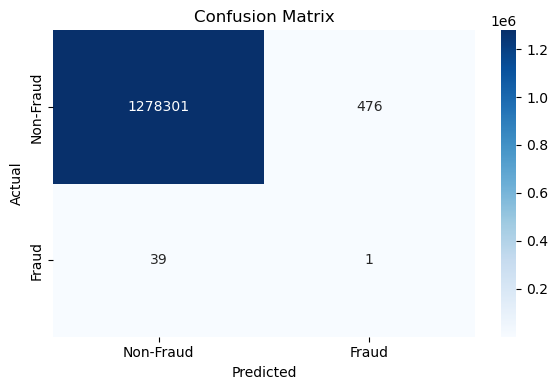

Recall/True Positive Rate: The model got 2.5% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 0.21% of correctly predicted fraud from all transactions that predicted as fraud
Alert Rate: The model will bring 0.04% of the records from total to the Alert rate


In [132]:
plot_confusion_matrix(df_rules_ml['Confirmed'], df_rules_ml['Alert']) # 5137

In [53]:
print("Num Records from Missed Fraud -- using Fraud Rules Alert:", len(df_rules_ml[(df_rules_ml['Alert'] == False) & (df_rules_ml['Confirmed'] == True)]))
print("Num Records from Missed Fraud -- using ML Alert:", len(df_rules_ml[(df_rules_ml['P_Bad'] < 0.1) & (df_rules_ml['Confirmed'] == True)]))

Num Records from Missed Fraud -- using Fraud Rules Alert: 39
Num Records from Missed Fraud -- using ML Alert: 8


In [52]:
print("Loss Amount (IDR) from Missed Fraud -- using Fraud Rules Alert:", df_rules_ml[(df_rules_ml['Alert'] == False) & (df_rules_ml['Confirmed'] == True)]['TransactionAmount'].sum())
print("Loss Amount (IDR) from Missed Fraud -- using ML Alert:", df_rules_ml[(df_rules_ml['P_Bad'] < 0.1) & (df_rules_ml['Confirmed'] == True)]['TransactionAmount'].sum())

Loss Amount (IDR) from Missed Fraud -- using Fraud Rules Alert: 2327743200.0
Loss Amount (IDR) from Missed Fraud -- using ML Alert: 290034560.0


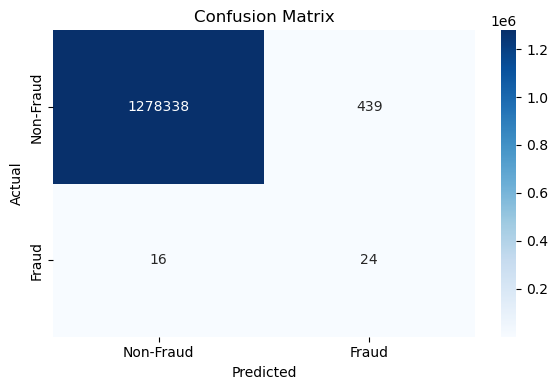

Recall/True Positive Rate: The model got 60.0% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 5.18% of correctly predicted fraud from all transactions that predicted as fraud
Alert Rate: The model will bring 0.04% of the records from total to the Alert rate


In [133]:
threshold = 0.198
plot_confusion_matrix(
    df_rules_ml['Confirmed'],
    df_rules_ml['P_Bad'],
    threshold
)

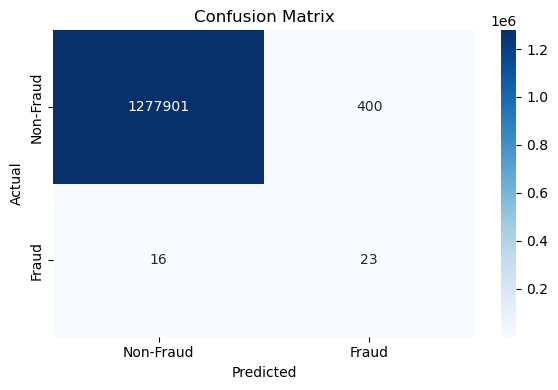

Recall/True Positive Rate: The model got 58.97% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 5.44% of correctly predicted fraud from all transactions that predicted as fraud
Alert Rate: The model will bring 0.03% of the records from total to the Alert rate


In [129]:
threshold = 0.198
plot_confusion_matrix(
    df_rules_ml[df_rules_ml['Alert']==False]['Confirmed'],
    df_rules_ml[df_rules_ml['Alert']==False]['P_Bad'],
    threshold
)

In [130]:
print("Loss Amount (IDR) from Missed Fraud -- using Fraud Rules Alert:", df_rules_ml[(df_rules_ml['Alert'] == False) & (df_rules_ml['Confirmed'] == True)]['TransactionAmount'].sum())
print("Loss Amount (IDR) from Missed Fraud -- using ML Alert:", df_rules_ml[(df_rules_ml['P_Bad'] < 0.198) & (df_rules_ml['Confirmed'] == True)]['TransactionAmount'].sum())

Loss Amount (IDR) from Missed Fraud -- using Fraud Rules Alert: 2327743200.0
Loss Amount (IDR) from Missed Fraud -- using ML Alert: 817943300.0


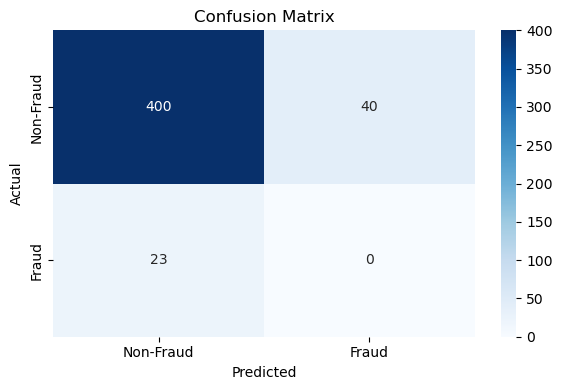

Recall/True Positive Rate: The model got 0.0% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 0.0% of correctly predicted fraud from all transactions that predicted as fraud
Alert Rate: The model will bring 8.64% of the records from total to the Alert rate


In [127]:
plot_confusion_matrix(
    df_rules_ml[(df_rules_ml['P_Bad'] >= 0.198)]['Confirmed'],
    df_rules_ml[(df_rules_ml['P_Bad'] >= 0.198)]['Alert']
)

In [106]:
print("Num Records from Missed Fraud -- using ML Alert:", len(df_rules_ml[(df_rules_ml['P_Bad'] < 0.165) & (df_rules_ml['Confirmed'] == True)]))
print("Loss Amount (IDR) from Missed Fraud -- using ML Alert:", df_rules_ml[(df_rules_ml['P_Bad'] < 0.165) & (df_rules_ml['Confirmed'] == True)]['TransactionAmount'].sum())

Num Records from Missed Fraud -- using ML Alert: 14
Loss Amount (IDR) from Missed Fraud -- using ML Alert: 799443300.0


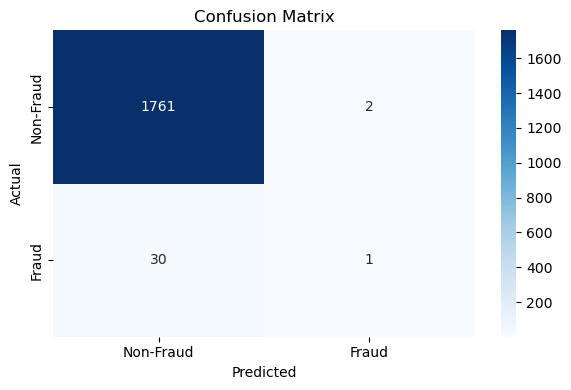

Recall/True Positive Rate: The model got 3.23% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 33.33% of correctly predicted fraud from all transactions that predicted as fraud
Alert Rate: The model will bring 0.17% of the records from total to the Alert rate


In [64]:
plot_confusion_matrix(
    df_rules_ml[(df_rules_ml['P_Bad'] >= 0.1)]['Confirmed'],
    df_rules_ml[(df_rules_ml['P_Bad'] >= 0.1)]['P_Bad'],
    0.58
)

In [65]:
print("Loss Amount (IDR) from Good Transactions Rejected -- using ML Alert:", df_rules_ml[(df_rules_ml['P_Bad'] >= 0.58) & (df_rules_ml['Confirmed'] == False)]['TransactionAmount'].sum())
print("Save Amount (IDR) from Actual Fraud Captured -- using ML Alert:", df_rules_ml[(df_rules_ml['P_Bad'] >= 0.58) & (df_rules_ml['Confirmed'] == True)]['TransactionAmount'].sum())

Loss Amount (IDR) from Good Transactions Rejected -- using ML Alert: 25317500.0
Save Amount (IDR) from Actual Fraud Captured -- using ML Alert: 6150000.0


In [134]:
df_rules_ml

,Triggered_Rules,Alert,TransactionAmount,P_Bad,Confirmed
Transaction Serial No,,,,,
1129534865,,False,1421100.0,0.008918,0
1128898865,,False,2200000.0,0.007938,0
1128898869,,False,130000.0,0.001724,0
1128898873,,False,0.0,0.000000,0
1128898882,,False,0.0,0.000975,0
...,...,...,...,...,...
1143915808,,False,0.0,0.000000,0
1143915813,,False,0.0,0.000000,0
1143915820,,False,0.0,0.000000,0


# Taking Out DBank Web Analysis

In [135]:
dbank_web = pd.read_csv("data/others/tsn_dbank_web.csv")

In [142]:
df_rules_ml_new = df_rules_ml.loc[~df_rules_ml.index.isin(dbank_web['Transaction_Serial_No'])].copy()

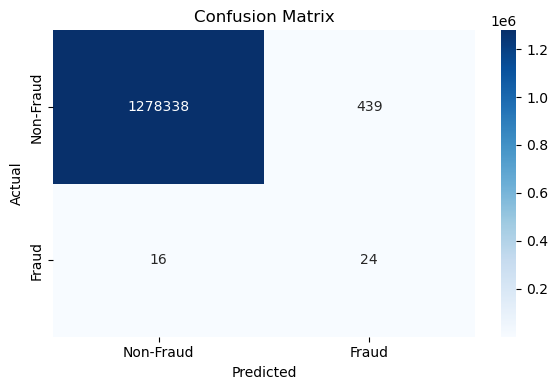

Recall/True Positive Rate: The model got 60.0% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 5.18% of correctly predicted fraud from all transactions that predicted as fraud
Alert Rate: The model will bring 0.04% of the records from total to the Alert rate


In [144]:
threshold = 0.198
plot_confusion_matrix(
    df_rules_ml['Confirmed'],
    df_rules_ml['P_Bad'],
    threshold
)

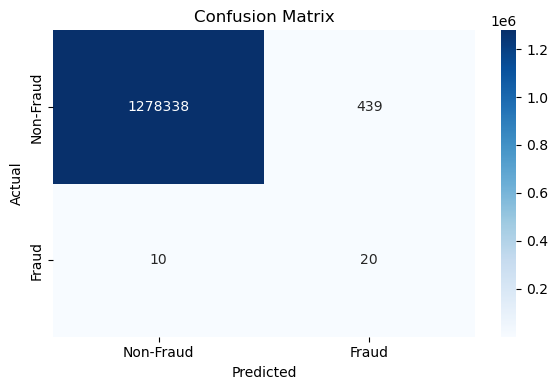

Recall/True Positive Rate: The model got 66.67% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 4.36% of correctly predicted fraud from all transactions that predicted as fraud
Alert Rate: The model will bring 0.04% of the records from total to the Alert rate


In [143]:
threshold = 0.198
plot_confusion_matrix(
    df_rules_ml_new['Confirmed'],
    df_rules_ml_new['P_Bad'],
    threshold
)

In [145]:
from sklearn.metrics import f1_score
from tqdm import trange

In [147]:
threshold = 0.198
y_true_no_web = df_rules_ml_new['Confirmed']
y_pred_no_web = df_rules_ml_new['P_Bad'] > threshold
y_true_with_web = df_rules_ml['Confirmed']
y_pred_with_web = df_rules_ml['P_Bad'] > threshold

# Num of bootstrap iterations
n_boot = 10000
rng = np.random.default_rng(42)

diffs = []

for _ in trange(n_boot):
    # resample WITH replacement for each dataset
    idx_no_web = rng.integers(0, len(y_true_no_web), len(y_true_no_web))
    idx_with_web = rng.integers(0, len(y_true_with_web), len(y_true_with_web))

    f1_no_web = f1_score(
        np.array(y_true_no_web)[idx_no_web],
        np.array(y_pred_no_web)[idx_no_web]
    )

    f1_with_web = f1_score(
        np.array(y_true_with_web)[idx_with_web],
        np.array(y_pred_with_web)[idx_with_web]
    )

    diffs.append(f1_with_web - f1_no_web)

diffs = np.array(diffs)

# mean difference
mean_diff = diffs.mean()

# 95% confidence interval
ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])

# p-value (two-sided)
p_value = (np.sum(diffs <= 0) / n_boot) * 2

print(f"Mean F1 difference: {mean_diff:.4f}")
print(f"95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"p-value: {p_value:.4f}")

100%|██████████| 10000/10000 [2:49:07<00:00,  1.01s/it] 

Mean F1 difference: 0.0135
95% CI: [-0.0346, 0.0620]
p-value: 0.5910


In [156]:
import matplotlib.pyplot as plt

def plot_diffs(diffs, ci_low, ci_high, mean_diff):
    plt.figure(figsize=(8,5))
    plt.hist(diffs, bins=40, color="skyblue")
    plt.axvline(0.0, color="red", linestyle="--")
    plt.axvline(ci_low, color="green", linestyle="--",
                label=f"95% CI Low ({ci_low:.3f})")
    plt.axvline(ci_high, color="green", linestyle="--",
                label=f"95% CI High ({ci_high:.3f})")
    plt.axvline(mean_diff, color="blue", linestyle="-",
                label=f"Mean Delta F1 ({mean_diff:.3f})")
    plt.title("Bootstrap Delta F1-Score (with DBank Web - without Dbank Web)")
    plt.xlabel("Delta F1-Score")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

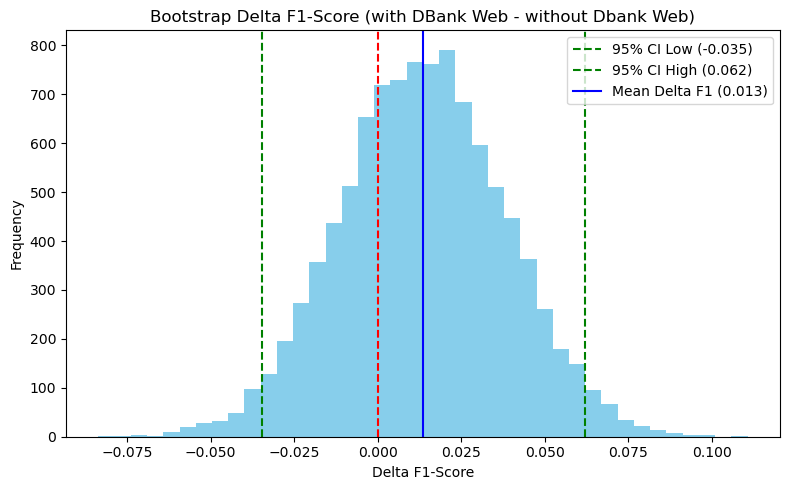

In [157]:
plot_diffs(diffs, ci_low, ci_high, mean_diff)